# Assignment 15 — Exercise Quality Score Regressor

**Pipeline:**  
Filter ugly recordings (A14 model) → Cut start/stop (A12 model) → Augment → Feature engineer → Fixed c frames → Train Dense / CNN / RNN regressors → Evaluate with MAE, MSE, Bland-Altman, correlation → MLflow

## Imports

In [1]:
import os, glob, sys, random, warnings, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr
import mlflow
import mlflow.pytorch
import dagshub
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

sys.path.append('../../scripts')
import ml_utils as mlutils


## Helpers & Model Classes

In [2]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def get_feat_cols(columns):
    return [c for c in columns if '_3d_' in c]


class ActivityGatekeeper(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bidirectional = config.get('bidirectional', False)
        mult    = 2 if self.bidirectional else 1
        rnn_cls = nn.GRU if config.get('rnn_type','LSTM') == 'GRU' else nn.LSTM
        self.rnn = rnn_cls(
            config['input_size'], config['hidden_size'], config['num_layers'],
            batch_first=True,
            dropout=config['dropout'] if config['num_layers'] > 1 else 0,
            bidirectional=self.bidirectional,
        )
        act = config.get('activation', 'identity')
        self.act = nn.ReLU() if act=='relu' else (nn.Tanh() if act=='tanh' else nn.Identity())
        self.fc  = nn.Linear(config['hidden_size'] * mult, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(self.act(out[:, -1, :]))
    
def to_fixed_length(arr, c=10):
    n=len(arr)
    if n==c: return arr
    if n<c:
        return np.vstack([arr, np.zeros((c-n,arr.shape[1]),'float32')])
    idx=np.round(np.linspace(0,n-1,c)).astype(int)
    return arr[idx]


## MLflow & Device Setup

In [3]:
dagshub.init(repo_owner='SamuelFredricBerg', repo_name='4dt907', mlflow=True)

PROJECT   = 'Score_Regressor_A15_V2'
utils     = mlutils.mlutils(PROJECT)
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PLOTS_DIR = 'plots_a15'
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f'Device: {device}')


Accessing as Soppa22

Initialized MLflow to track repo "SamuelFredricBerg/4dt907"

Repository SamuelFredricBerg/4dt907 initialized!

Device: cpu


## Load Ground-Truth Scores

Score range: 0.000 – 4.000
Mean: 2.000  Std: 0.7207


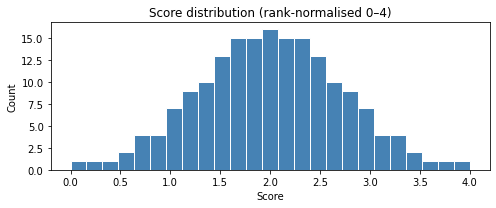

In [4]:
SCORE_MAX = 4.0

from scipy.stats import norm

scores_df = pd.read_csv('../../data/scores_a15.csv')
scores_df.columns = ['filename', 'score']

# Sort by score, assign ranks, map to normal distribution
scores_df = scores_df.sort_values('score').reset_index(drop=True)
n = len(scores_df)

# Map rank to quantile, then to normal distribution scaled to 0–4
quantiles = (scores_df.index + 0.5) / n          # evenly spaced quantiles 0–1
scores_df['score'] = norm.ppf(quantiles)           # inverse normal → mean=0 std=1
scores_df['score'] = (scores_df['score'] - scores_df['score'].min()) / \
                     (scores_df['score'].max() - scores_df['score'].min()) * SCORE_MAX

scores_map = dict(zip(scores_df['filename'].str.replace('_kinect',''), scores_df['score']))

print(f'Score range: {scores_df.score.min():.3f} – {scores_df.score.max():.3f}')
print(f'Mean: {scores_df.score.mean():.3f}  Std: {scores_df.score.std():.4f}')
plt.figure(figsize=(7,3))
plt.hist(scores_df['score'], bins=25, color='steelblue', edgecolor='white')
plt.xlabel('Score'); plt.ylabel('Count'); plt.title('Score distribution (rank-normalised 0–4)')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR,'score_dist.png'),dpi=120); plt.show()


In [5]:
KEY_DIST_PAIRS = [
    ('left_shoulder','right_shoulder'),('left_elbow','right_elbow'),
    ('left_wrist','right_wrist'),('left_hip','right_hip'),
    ('left_knee','right_knee'),('left_ankle','right_ankle'),
    ('left_shoulder','left_elbow'),('left_elbow','left_wrist'),
    ('right_shoulder','right_elbow'),('right_elbow','right_wrist'),
    ('left_hip','left_knee'),('left_knee','left_ankle'),
    ('right_hip','right_knee'),('right_knee','right_ankle'),
    ('left_shoulder','left_hip'),('right_shoulder','right_hip'),
]
KEY_ANGLE_TRIPLES = [
    ('left_shoulder','left_elbow','left_wrist'),
    ('right_shoulder','right_elbow','right_wrist'),
    ('left_hip','left_knee','left_ankle'),
    ('right_hip','right_knee','right_ankle'),
    ('left_elbow','left_shoulder','left_hip'),
    ('right_elbow','right_shoulder','right_hip'),
]

def _pos(arr, fc, joint):
    idxs=[]
    for ax in ['x','y','z']:
        col=f'{joint}_3d_{ax}'
        if col not in fc: return None
        idxs.append(fc.index(col))
    return arr[:,idxs]

def add_features(arr, fc):
    extras=[]
    pls=_pos(arr,fc,'left_shoulder'); prs=_pos(arr,fc,'right_shoulder')
    scale = np.linalg.norm(prs-pls,axis=1,keepdims=True).mean()+1e-8 if pls is not None and prs is not None else 1.0
    for j1,j2 in KEY_DIST_PAIRS:
        p1,p2=_pos(arr,fc,j1),_pos(arr,fc,j2)
        if p1 is not None and p2 is not None:
            extras.append(np.linalg.norm(p2-p1,axis=1,keepdims=True)/scale)
    for ja,jv,jb in KEY_ANGLE_TRIPLES:
        pa,pv,pb=_pos(arr,fc,ja),_pos(arr,fc,jv),_pos(arr,fc,jb)
        if pa is not None and pv is not None and pb is not None:
            va,vb=pa-pv,pb-pv
            cos=(np.sum(va*vb,axis=1)/(np.linalg.norm(va,axis=1)*np.linalg.norm(vb,axis=1)+1e-8))
            extras.append(cos.reshape(-1,1))
    return np.hstack([arr]+extras).astype('float32') if extras else arr


## Load Filter & Cut Models

In [6]:
# ── A12 start/stop model ─────────────────────────────────────────────────────
SS_CONFIG = {
    'rnn_type':'LSTM','bidirectional':False,'hidden_size':128,'num_layers':2,
    'seq_length':5,'input_size':39,'dropout':0.1,'activation':'identity','use_scaling':False,
}
ss_model = ActivityGatekeeper(SS_CONFIG).to(device)
ss_model.load_state_dict(torch.load('best_start_stop_model_prod.pth', map_location=device, weights_only=True))
ss_model.eval()
print('Start/stop model loaded')


# ── Good/Bad classifier from DagShub ─────────────────────────────────────────
with open('goodbad_config.json') as f:
    gb_cfg = json.load(f)

gb_type     = gb_cfg.get('model_type', 'dense')
GB_C        = 10
GB_N_FEAT   = 61   # 39 coords + 16 distances + 6 angles

class _GBDense(nn.Module):
    def __init__(self):
        super().__init__()
        h1 = int(gb_cfg['h1']); h2 = int(gb_cfg['h2'])
        dr = float(gb_cfg['dropout'])
        idim = GB_C * GB_N_FEAT
        self.net = nn.Sequential(
            nn.Linear(idim,h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dr),
            nn.Linear(h1,h2), nn.ReLU(), nn.Linear(h2,1))
    def forward(self,x): return self.net(x)

class _GBCNN(nn.Module):
    def __init__(self):
        super().__init__()
        nf = int(gb_cfg['n_filters']); ks = int(gb_cfg['kernel_size'])
        ps = int(gb_cfg['pool_size']); fh = int(gb_cfg['fc_h'])
        dr = float(gb_cfg['dropout'])
        co = nf * (GB_C // ps)
        self.conv = nn.Sequential(nn.Conv1d(GB_N_FEAT,nf,ks,padding=ks//2),nn.ReLU(),nn.MaxPool1d(ps))
        self.fc   = nn.Sequential(nn.Flatten(),nn.Dropout(dr),nn.Linear(co,fh),nn.ReLU(),nn.Linear(fh,1))
    def forward(self,x): return self.fc(self.conv(x.permute(0,2,1)))

gb_model = (_GBDense() if gb_type == 'dense' else _GBCNN()).to(device)
gb_model.load_state_dict(torch.load('best_goodbad_model_prod.pth', map_location=device, weights_only=True))
gb_model.eval()

gb_scaler = None
if os.path.exists('scaler_goodbad_prod.joblib'):
    gb_scaler = joblib.load('scaler_goodbad_prod.joblib')

print(f'Good/Bad classifier loaded: type={gb_type}  scaler={"yes" if gb_scaler else "no"}')


Start/stop model loaded
Good/Bad classifier loaded: type=cnn  scaler=yes


## Filter Ugly & Cut Sequences

In [7]:
DATA_DIR = '../../data/kinect_good_preprocessed_not_cut_A11_mediapipe'
C        = 10
MIN_SEQ  = C


def cut_with_model(df, model, config, device, min_length=MIN_SEQ):
    feat_cols = get_feat_cols(df.columns)
    X = df[feat_cols].values.astype('float32')
    seq_len = config['seq_length']
    preds   = [0] * (seq_len - 1)
    with torch.no_grad():
        for i in range(len(df) - seq_len + 1):
            w    = torch.tensor(X[i:i+seq_len]).unsqueeze(0).to(device)
            prob = torch.sigmoid(model(w)).item()
            preds.append(1 if prob >= 0.5 else 0)
    active = np.where(np.array(preds)==1)[0]
    if len(active) == 0: return None
    cut = df.iloc[active[0]:active[-1]+1].reset_index(drop=True)
    return cut if len(cut) >= min_length else None


def is_good_squat(arr, feat_cols, model, scaler, model_type, c=GB_C):
    enriched = add_features(arr, feat_cols)
    fixed    = to_fixed_length(enriched, c)
    X = fixed.flatten()[None,:] if model_type == 'dense' else fixed[None,:,:]
    if scaler is not None:
        X = scaler.transform(X.reshape(1,-1)).reshape(X.shape)
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(torch.tensor(X, dtype=torch.float32, device=device))).item()
    return prob >= 0.5


all_csv = sorted(glob.glob(os.path.join(DATA_DIR,'*.csv')))
print(f'Found {len(all_csv)} CSV files')

raw_sequences = []
skipped_cut, skipped_score, skipped_goodbad = [], [], []

for f in tqdm(all_csv, desc='Cut+Filter'):
    key = os.path.splitext(os.path.basename(f))[0].replace('_kinect','')
    if key not in scores_map:
        skipped_score.append(key); continue

    df     = pd.read_csv(f)
    cut_df = cut_with_model(df, ss_model, SS_CONFIG, device)
    if cut_df is None:
        skipped_cut.append(key); continue

    feat_cols = get_feat_cols(cut_df.columns)
    feat_arr  = cut_df[feat_cols].values.astype('float32')

    if not is_good_squat(feat_arr, feat_cols, gb_model, gb_scaler, gb_type):
        skipped_goodbad.append(key); continue

    raw_sequences.append((feat_arr, scores_map[key], f, feat_cols))

print(f'Kept : {len(raw_sequences)}')
print(f'Skipped — no score: {len(skipped_score)}  bad cut: {len(skipped_cut)}  not squat: {len(skipped_goodbad)}')
FEAT_COLS = raw_sequences[0][3]

Found 180 CSV files


Cut+Filter: 100%|██████████| 180/180 [00:21<00:00,  8.31it/s]

Kept : 131
Skipped — no score: 0  bad cut: 0  not squat: 49


## Augmentation

In [8]:
LEFT_RIGHT_PAIRS = [
    ('left_shoulder','right_shoulder'),('left_elbow','right_elbow'),
    ('left_wrist','right_wrist'),('left_hip','right_hip'),
    ('left_knee','right_knee'),('left_ankle','right_ankle'),
]

def _col_idx(fc, joint, ax):
    try: return fc.index(f'{joint}_3d_{ax}')
    except ValueError: return -1

def aug_mirror(arr, fc):
    a = arr.copy()
    xi = [i for i,c in enumerate(fc) if c.endswith('_3d_x')]
    a[:,xi] = 1.0 - a[:,xi]
    for l,r in LEFT_RIGHT_PAIRS:
        for ax in ['x','y','z']:
            li,ri = _col_idx(fc,l,ax),_col_idx(fc,r,ax)
            if li==-1 or ri==-1: continue
            a[:,li],a[:,ri] = arr[:,ri].copy(),arr[:,li].copy()
            if ax=='x': a[:,li]=1-a[:,li]; a[:,ri]=1-a[:,ri]
    return a

def aug_rotate_y(arr, fc, deg):
    a=arr.copy(); t=np.radians(deg); c,s=np.cos(t),np.sin(t)
    xi=[i for i,col in enumerate(fc) if col.endswith('_3d_x')]
    zi=[i for i,col in enumerate(fc) if col.endswith('_3d_z')]
    for x,z in zip(xi,zi):
        xv,zv=arr[:,x].copy(),arr[:,z].copy()
        a[:,x]=c*xv+s*zv; a[:,z]=-s*xv+c*zv
    return a

def aug_scale(arr, fc, sx=1.0, sy=1.0, sz=1.0):
    a=arr.copy()
    for i,col in enumerate(fc):
        if col.endswith('_3d_x'): a[:,i]*=sx
        elif col.endswith('_3d_y'): a[:,i]*=sy
        elif col.endswith('_3d_z'): a[:,i]*=sz
    return a

def aug_noise(arr, sigma=0.005):
    return arr + np.random.normal(0,sigma,arr.shape).astype('float32')

def generate_variants(arr, fc):
    m = aug_mirror(arr,fc)
    return [
        arr, m,
        aug_rotate_y(arr,fc,-10), aug_rotate_y(arr,fc,-5),
        aug_rotate_y(arr,fc,5),  aug_rotate_y(arr,fc,10),
        aug_rotate_y(m,fc,-5),   aug_rotate_y(m,fc,5),
        aug_scale(arr,fc,0.95,0.95,0.95), aug_scale(arr,fc,1.05,1.05,1.05),
        aug_scale(m,fc,0.95,0.95,0.95),   aug_scale(m,fc,1.05,1.05,1.05),
        aug_noise(arr,0.005), aug_noise(arr,0.010), aug_noise(m,0.005),
    ]

augmented_pool = []
for gid,(arr,score,fpath,fc) in enumerate(tqdm(raw_sequences,desc='Augmenting')):
    for v in generate_variants(arr,fc):
        augmented_pool.append((v, score, gid))

N_VARIANTS_PER = len(generate_variants(raw_sequences[0][0], FEAT_COLS))
orig_indices   = np.arange(0, len(augmented_pool), N_VARIANTS_PER)
print(f'Pool: {len(augmented_pool)} sequences ({N_VARIANTS_PER} variants each)')


Augmenting: 100%|██████████| 131/131 [00:00<00:00, 687.33it/s]

Pool: 1965 sequences (15 variants each)


## Fixed-Size Sequences (c frames)

In [9]:
X_seq, y_all, grp_all = [], [], []
for arr,score,gid in tqdm(augmented_pool,desc='Building sequences'):
    enriched = add_features(arr, FEAT_COLS)
    fixed    = to_fixed_length(enriched, C)
    X_seq.append(fixed); y_all.append(score); grp_all.append(gid)

X_seq   = np.array(X_seq,  dtype='float32')
X_flat  = X_seq.reshape(len(X_seq),-1)
y_all   = np.array(y_all,  dtype='float32')
grp_all = np.array(grp_all)

N_FEAT      = X_seq.shape[2]
INPUT_DENSE = X_flat.shape[1]
print(f'Shape: {X_seq.shape}  Dense input: {INPUT_DENSE}  Score range: {y_all.min():.2f}–{y_all.max():.2f}')


Building sequences: 100%|██████████| 1965/1965 [00:00<00:00, 2279.42it/s]

Shape: (1965, 10, 61)  Dense input: 610  Score range: 0.00–3.49


## Model Definitions

In [10]:
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)


class ADense(nn.Module):
    def __init__(self, input_dim, h1, h2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1,h2), nn.ReLU(), nn.Linear(h2,1)
        )
        for m in self.modules():
            if isinstance(m,nn.Linear): init.xavier_uniform_(m.weight)
    def forward(self,x): return self.net(x)


class ACNN(nn.Module):
    def __init__(self, n_feat, seq_len=C, n_filters=8, kernel_size=3, pool_size=2, fc_h=16, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_feat,n_filters,kernel_size,padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool_size))
        co = n_filters*(seq_len//pool_size)
        self.fc = nn.Sequential(nn.Flatten(),nn.Dropout(dropout),nn.Linear(co,fc_h),nn.ReLU(),nn.Linear(fc_h,1))
        for m in self.modules():
            if isinstance(m,nn.Linear): init.xavier_uniform_(m.weight)
            elif isinstance(m,nn.Conv1d): init.kaiming_normal_(m.weight)
    def forward(self,x): return self.fc(self.conv(x.permute(0,2,1)))


class ARNN(nn.Module):
    def __init__(self, n_feat, hidden=32, num_layers=1, rnn_type='GRU', dropout=0.0):
        super().__init__()
        rnn_cls  = nn.GRU if rnn_type=='GRU' else nn.LSTM
        self.rnn = rnn_cls(n_feat,hidden,num_layers,batch_first=True,
                           dropout=dropout if num_layers>1 else 0)
        self.fc  = nn.Linear(hidden,1)
        init.xavier_uniform_(self.fc.weight)
    def forward(self,x):
        out,_ = self.rnn(x); return self.fc(out[:,-1,:])


_h1 = max(8, int(9000/INPUT_DENSE))
_h2 = max(4, _h1//2)
_d  = ADense(INPUT_DENSE,_h1,_h2)
_c  = ACNN(N_FEAT,C)
_r  = ARNN(N_FEAT)
print(f'ADense {count_params(_d):,}  ACNN {count_params(_c):,}  ARNN {count_params(_r):,}')


ADense 8,695  ACNN 2,145  ARNN 9,153


## Training Utilities & Plots

In [11]:
from contextlib import nullcontext

class ScoreDataset(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return self.X[i],self.y[i]


def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss=0.0; preds=[]; targets=[]
    ctx = nullcontext() if train else torch.no_grad()
    with ctx:
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            if train: optimizer.zero_grad()
            out=model(xb); loss=criterion(out,yb)
            if train: loss.backward(); optimizer.step()
            total_loss+=loss.item()
            preds.extend(out.detach().cpu().numpy().flatten())
            targets.extend(yb.cpu().numpy().flatten())
    p=np.array(preds); t=np.array(targets)
    return total_loss/len(loader), float(np.mean((p-t)**2)), float(np.mean(np.abs(p-t)))


def evaluate(model, loader, device):
    model.eval(); preds=[]; targets=[]
    with torch.no_grad():
        for xb,yb in loader:
            preds.extend(model(xb.to(device)).cpu().numpy().flatten())
            targets.extend(yb.numpy().flatten())
    p=np.array(preds); t=np.array(targets)
    mse=float(np.mean((p-t)**2)); mae=float(np.mean(np.abs(p-t)))
    return {'MSE':mse,'MAE':mae,'RMSE':float(np.sqrt(mse)),'preds':p,'targets':t}


def _pad(lst,n):
    return lst+[lst[-1]]*(n-len(lst)) if lst else [0.0]*n


def plot_curves(histories, note, n_params):
    max_ep=max(len(h['tl']) for h in histories)
    e=np.arange(1,max_ep+1)
    def avg(k): return np.mean([_pad(h[k],max_ep) for h in histories],axis=0)
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    fig.suptitle(f'{note}  ({n_params:,} params)')
    for ax,(tk,vk,lbl) in zip(axes,[('tl','vl','Loss'),('tm','vm','MSE'),('ta','va','MAE')]):
        ax.plot(e,avg(tk),'-',label='Train',color='steelblue')
        ax.plot(e,avg(vk),'--',label='Val',color='steelblue',alpha=0.7)
        ax.set_xlabel('Epoch'); ax.set_title(lbl); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    p=os.path.join(PLOTS_DIR,f'curves_{note}.png')
    fig.savefig(p,dpi=120,bbox_inches='tight'); plt.show(); plt.close(fig)
    return p


def plot_evaluation(preds, targets, note, metrics):
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    fig.suptitle(f'{note} — MSE={metrics["MSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
                 f'RMSE={metrics["RMSE"]:.4f}')

    # Predicted vs True
    r,_ = pearsonr(targets,preds)
    lo,hi = min(targets.min(),preds.min()),max(targets.max(),preds.max())
    axes[0].scatter(targets,preds,alpha=0.5,color='steelblue',s=15)
    axes[0].plot([lo,hi],[lo,hi],'r--',lw=1)
    axes[0].set_xlabel('True score'); axes[0].set_ylabel('Predicted score')
    axes[0].set_title(f'Pred vs True  r={r:.3f}')

    # Bland-Altman
    mean_val = (preds+targets)/2
    diff     = preds-targets
    md_val   = diff.mean(); sd_val = diff.std()
    axes[1].scatter(mean_val,diff,alpha=0.5,color='steelblue',s=15)
    axes[1].axhline(md_val,color='red',lw=1.5,label=f'Mean {md_val:.3f}')
    axes[1].axhline(md_val+1.96*sd_val,color='red',lw=1,linestyle='--',label='+1.96 SD')
    axes[1].axhline(md_val-1.96*sd_val,color='red',lw=1,linestyle='--',label='-1.96 SD')
    axes[1].axhline(0,color='gray',lw=0.8)
    axes[1].set_xlabel('Mean of pred & true'); axes[1].set_ylabel('Pred - True')
    axes[1].set_title('Bland-Altman'); axes[1].legend(fontsize=7)

    # Residual histogram
    axes[2].hist(diff,bins=20,color='steelblue',edgecolor='white')
    axes[2].axvline(0,color='red',linestyle='--')
    axes[2].set_xlabel('Residual'); axes[2].set_title('Residuals')

    plt.tight_layout()
    p=os.path.join(PLOTS_DIR,f'eval_{note}.png')
    fig.savefig(p,dpi=120,bbox_inches='tight'); plt.show(); plt.close(fig)
    return p


## Experiment Configuration

In [12]:
N_FOLDS = 10
SEED    = 42
set_seed(SEED)

ALL_VARIANTS = [
    {'note':'ADense_v1','model_type':'dense','h1':_h1,'h2':_h2,'dropout':0.3,
     'lr':1e-3,'batch_size':32,'epochs':100,'patience':12,'use_scaling':True},
    {'note':'ADense_v2','model_type':'dense','h1':_h1,'h2':_h2,'dropout':0.1,
     'lr':5e-4,'batch_size':64,'epochs':100,'patience':12,'use_scaling':True},
    {'note':'ACNN_v1','model_type':'cnn','n_filters':8,'kernel_size':3,'pool_size':2,
     'fc_h':16,'dropout':0.3,'lr':1e-3,'batch_size':32,'epochs':100,'patience':12,'use_scaling':True},
    {'note':'ACNN_v2','model_type':'cnn','n_filters':4,'kernel_size':5,'pool_size':2,
     'fc_h':8,'dropout':0.3,'lr':5e-4,'batch_size':32,'epochs':100,'patience':12,'use_scaling':True},
    {'note':'ARNN_GRU','model_type':'rnn','rnn_type':'GRU','hidden':32,'num_layers':1,
     'dropout':0.0,'lr':1e-3,'batch_size':32,'epochs':100,'patience':12,'use_scaling':True},
    {'note':'ARNN_LSTM','model_type':'rnn','rnn_type':'LSTM','hidden':32,'num_layers':1,
     'dropout':0.0,'lr':5e-4,'batch_size':32,'epochs':100,'patience':12,'use_scaling':True},
]
print(f'{len(ALL_VARIANTS)} variants')


6 variants


## 10-Fold Cross-Validation + MLflow

  Fold  1 | MSE=0.2821  MAE=0.4011  RMSE=0.5311
  Fold  2 | MSE=0.1798  MAE=0.3637  RMSE=0.4240
  Fold  3 | MSE=0.1202  MAE=0.2667  RMSE=0.3467
  Fold  4 | MSE=0.2811  MAE=0.4596  RMSE=0.5302
  Fold  5 | MSE=0.2358  MAE=0.4080  RMSE=0.4856
  Fold  6 | MSE=0.3387  MAE=0.5087  RMSE=0.5820
  Fold  7 | MSE=0.2103  MAE=0.3633  RMSE=0.4586
  Fold  8 | MSE=0.1516  MAE=0.3315  RMSE=0.3894
  Fold  9 | MSE=0.2939  MAE=0.3831  RMSE=0.5422
  Fold 10 | MSE=0.0886  MAE=0.2613  RMSE=0.2976

--- ADense_v1 (8,695 params) ---
10-fold: MSE=0.2182  MAE=0.3747  RMSE=0.4587


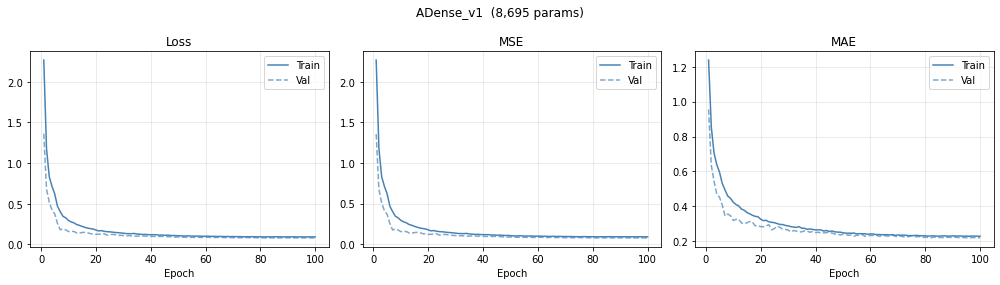

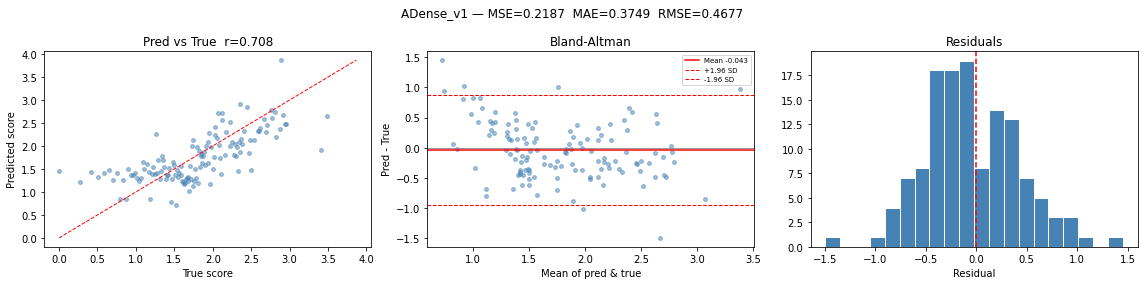

Comparing 0.3746877580881119 < 20
New Best! 0.3746877580881119  20. Updating models on DagsHub


2026/05/25 09:57:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 09:57:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'Score_Regressor_A15_V2' already exists. Creating a new version of this model...
2026/05/25 09:57:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Score_Regressor_A15_V2, version 3
Created version '3' of model 'Score_Regressor_A15_V2'.


Registered ADense_v1 -> @dev (v3)
🏃 View run A15 - ADense_v1 at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/58ee20c54cb1424f8b3ec65806d9d702
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.2347  MAE=0.4080  RMSE=0.4845
  Fold  2 | MSE=0.1996  MAE=0.3878  RMSE=0.4468
  Fold  3 | MSE=0.2494  MAE=0.3855  RMSE=0.4994
  Fold  4 | MSE=0.2752  MAE=0.4659  RMSE=0.5246
  Fold  5 | MSE=0.3390  MAE=0.4697  RMSE=0.5823
  Fold  6 | MSE=0.3577  MAE=0.5112  RMSE=0.5981
  Fold  7 | MSE=0.2856  MAE=0.4355  RMSE=0.5344
  Fold  8 | MSE=0.2500  MAE=0.3608  RMSE=0.5000
  Fold  9 | MSE=0.2961  MAE=0.3906  RMSE=0.5442
  Fold 10 | MSE=0.1369  MAE=0.2986  RMSE=0.3700

--- ADense_v2 (8,695 params) ---
10-fold: MSE=0.2624  MAE=0.4114  RMSE=0.5084


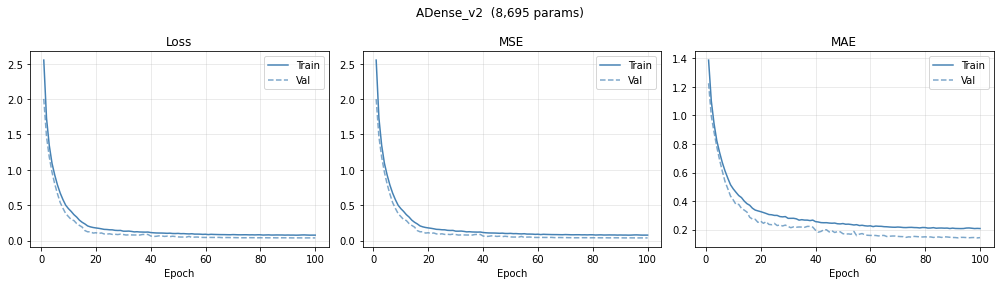

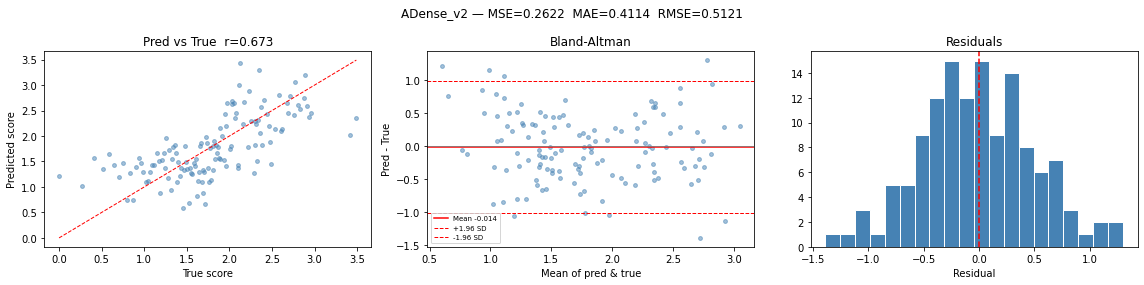

Comparing 0.4113771229982376 < 0.3746877580881119
  ADense_v2 did not beat @dev
🏃 View run A15 - ADense_v2 at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/963131181b5841f19c37282b3c9b863a
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.3078  MAE=0.4365  RMSE=0.5548
  Fold  2 | MSE=0.1839  MAE=0.3167  RMSE=0.4288
  Fold  3 | MSE=0.1088  MAE=0.2741  RMSE=0.3299
  Fold  4 | MSE=0.2869  MAE=0.4529  RMSE=0.5356
  Fold  5 | MSE=0.1786  MAE=0.3508  RMSE=0.4226
  Fold  6 | MSE=0.2708  MAE=0.4518  RMSE=0.5203
  Fold  7 | MSE=0.2151  MAE=0.3870  RMSE=0.4638
  Fold  8 | MSE=0.1837  MAE=0.3722  RMSE=0.4287
  Fold  9 | MSE=0.2029  MAE=0.3392  RMSE=0.4505
  Fold 10 | MSE=0.0992  MAE=0.2604  RMSE=0.3150

--- ACNN_v1 (2,145 params) ---
10-fold: MSE=0.2038  MAE=0.3642  RMSE=0.4450


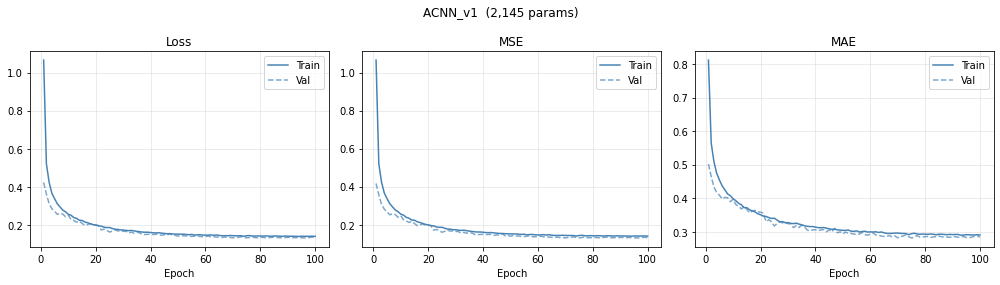

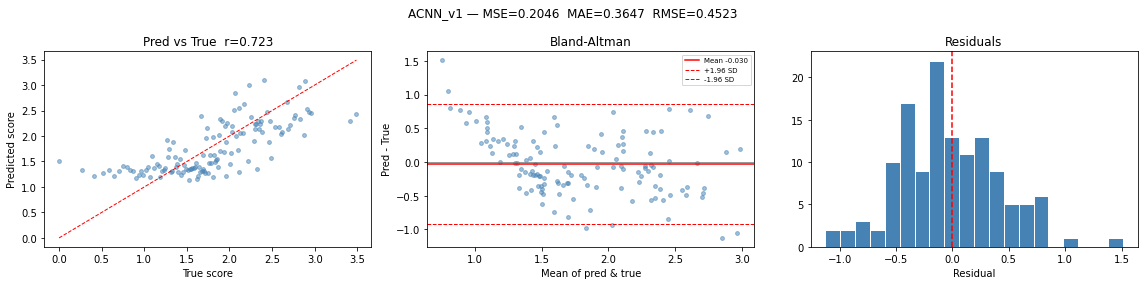

Comparing 0.36416110396385193 < 0.3746877580881119
New Best! 0.36416110396385193  0.3746877580881119. Updating models on DagsHub


2026/05/25 09:59:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 09:59:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'Score_Regressor_A15_V2' already exists. Creating a new version of this model...
2026/05/25 09:59:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Score_Regressor_A15_V2, version 4
Created version '4' of model 'Score_Regressor_A15_V2'.


Registered ACNN_v1 -> @dev (v4)
🏃 View run A15 - ACNN_v1 at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/ce42fe4a3f234b5da149164b041b9d43
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.2948  MAE=0.4442  RMSE=0.5429
  Fold  2 | MSE=0.1955  MAE=0.3502  RMSE=0.4422
  Fold  3 | MSE=0.1063  MAE=0.2532  RMSE=0.3261
  Fold  4 | MSE=0.4097  MAE=0.5396  RMSE=0.6401
  Fold  5 | MSE=0.2784  MAE=0.4285  RMSE=0.5277
  Fold  6 | MSE=0.3394  MAE=0.5005  RMSE=0.5826
  Fold  7 | MSE=0.3277  MAE=0.4660  RMSE=0.5724
  Fold  8 | MSE=0.1501  MAE=0.3277  RMSE=0.3874
  Fold  9 | MSE=0.4736  MAE=0.5368  RMSE=0.6882
  Fold 10 | MSE=0.1632  MAE=0.3499  RMSE=0.4040

--- ACNN_v2 (1,401 params) ---
10-fold: MSE=0.2739  MAE=0.4197  RMSE=0.5113


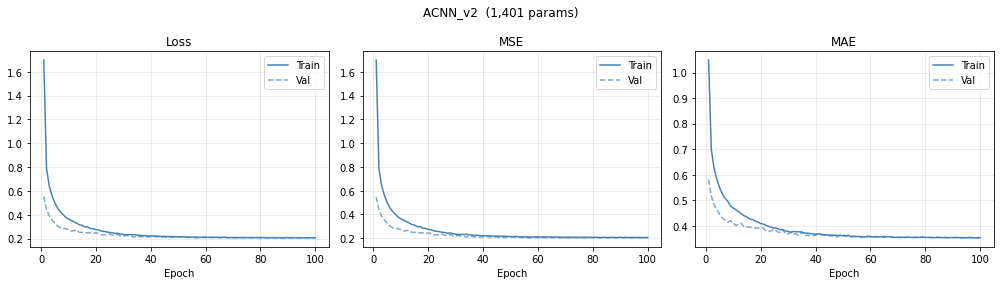

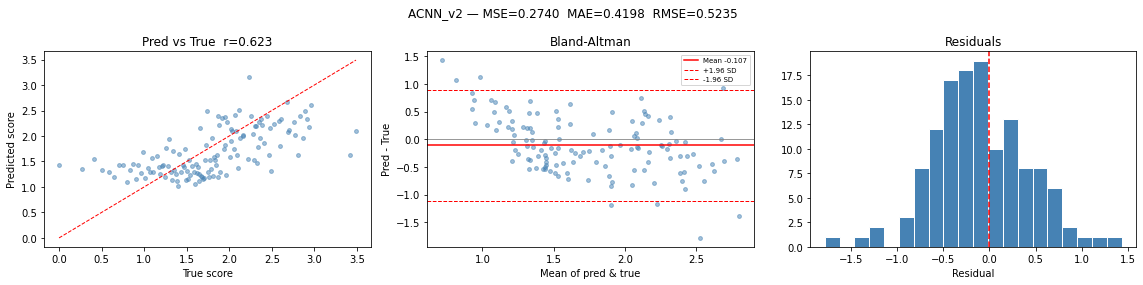

Comparing 0.41965276598930357 < 0.36416110396385193
  ACNN_v2 did not beat @dev
🏃 View run A15 - ACNN_v2 at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/53ba9862d1fd43bc91d3eaded2e8a99a
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.4424  MAE=0.5623  RMSE=0.6651
  Fold  2 | MSE=0.2412  MAE=0.4425  RMSE=0.4911
  Fold  3 | MSE=0.1792  MAE=0.3161  RMSE=0.4233
  Fold  4 | MSE=0.2484  MAE=0.4503  RMSE=0.4984
  Fold  5 | MSE=0.6043  MAE=0.5908  RMSE=0.7774
  Fold  6 | MSE=0.3635  MAE=0.4734  RMSE=0.6029
  Fold  7 | MSE=0.2457  MAE=0.3802  RMSE=0.4957
  Fold  8 | MSE=0.1408  MAE=0.3086  RMSE=0.3752
  Fold  9 | MSE=0.6694  MAE=0.6029  RMSE=0.8181
  Fold 10 | MSE=0.1779  MAE=0.3721  RMSE=0.4218

--- ARNN_GRU (9,153 params) ---
10-fold: MSE=0.3313  MAE=0.4499  RMSE=0.5569


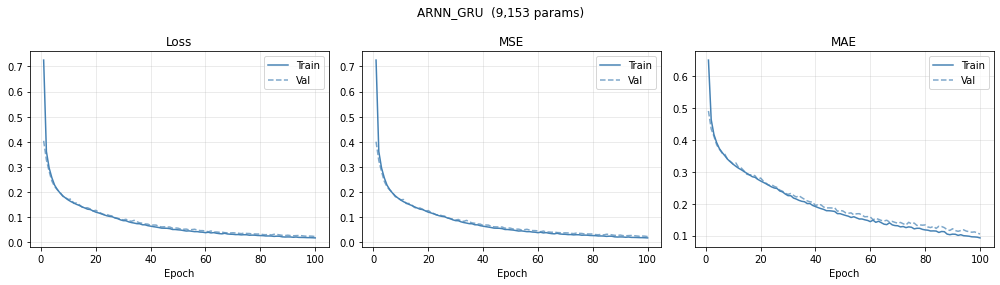

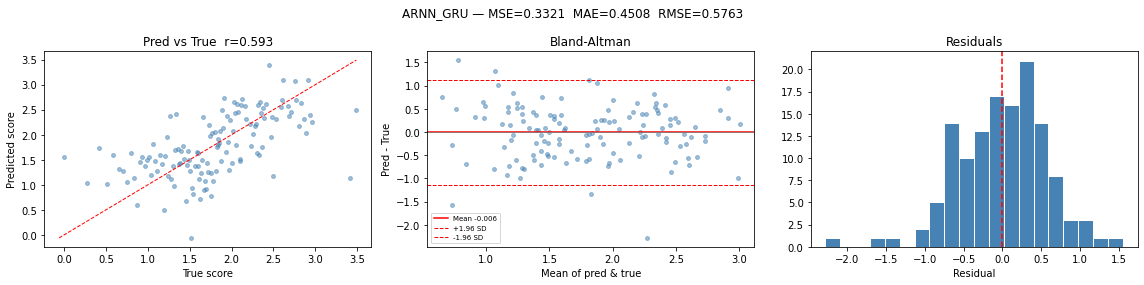

Comparing 0.44991437792778016 < 0.36416110396385193
  ARNN_GRU did not beat @dev
🏃 View run A15 - ARNN_GRU at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/c6f7edd067c84687858173e3ba764cb0
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.2236  MAE=0.3882  RMSE=0.4728
  Fold  2 | MSE=0.2403  MAE=0.4314  RMSE=0.4902
  Fold  3 | MSE=0.1081  MAE=0.2161  RMSE=0.3288
  Fold  4 | MSE=0.2898  MAE=0.4601  RMSE=0.5383
  Fold  5 | MSE=0.3970  MAE=0.5088  RMSE=0.6300
  Fold  6 | MSE=0.2685  MAE=0.4609  RMSE=0.5182
  Fold  7 | MSE=0.3636  MAE=0.4568  RMSE=0.6030
  Fold  8 | MSE=0.1390  MAE=0.3304  RMSE=0.3729
  Fold  9 | MSE=0.3139  MAE=0.3774  RMSE=0.5603
  Fold 10 | MSE=0.3324  MAE=0.4478  RMSE=0.5765

--- ARNN_LSTM (12,193 params) ---
10-fold: MSE=0.2676  MAE=0.4078  RMSE=0.5091


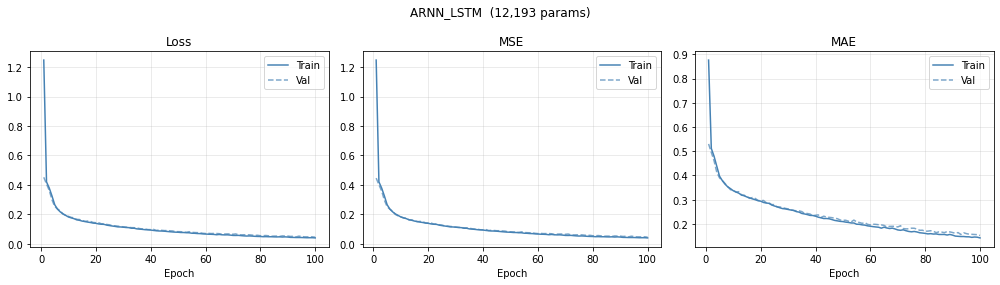

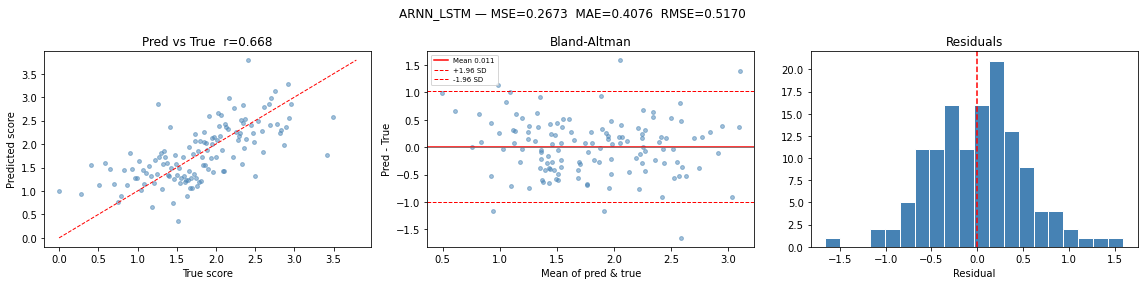

Comparing 0.4077914834022522 < 0.36416110396385193
  ARNN_LSTM did not beat @dev
🏃 View run A15 - ARNN_LSTM at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/d21a4ffc34eb409bb45c9588c6c05a2a
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0


In [13]:
def build_model(config):
    mt=config['model_type']
    if mt=='dense': return ADense(INPUT_DENSE,config['h1'],config['h2'],config['dropout'])
    if mt=='cnn':   return ACNN(N_FEAT,C,config['n_filters'],config['kernel_size'],
                                config['pool_size'],config['fc_h'],config['dropout'])
    return ARNN(N_FEAT,config['hidden'],config['num_layers'],config['rnn_type'],config['dropout'])

def get_X(config, indices):
    return X_flat[indices] if config['model_type']=='dense' else X_seq[indices]


all_variant_results = []

for config in ALL_VARIANTS:
    set_seed(SEED)
    note        = config['note']
    ckpt_path   = f'best_{note}.pth'
    scaler_path = f'scaler_{note}.joblib'
    for p in (ckpt_path, scaler_path):
        if os.path.exists(p): os.remove(p)

    _demo    = build_model(config)
    n_params = count_params(_demo); del _demo

    gkf         = GroupKFold(n_splits=N_FOLDS)
    orig_groups = grp_all[orig_indices]
    orig_y      = y_all[orig_indices]

    with mlflow.start_run(run_name=f'A15 - {note}') as run:
        log_cfg = {k:v for k,v in config.items()}
        log_cfg.update({'c_frames':C,'n_features':N_FEAT,'input_dim':INPUT_DENSE,'n_params':n_params})
        mlflow.log_params(log_cfg)

        fold_results=[]; fold_histories=[]
        agg_preds=[]; agg_targets=[]
        best_overall_mse=float('inf')

        for fold,(tr_orig,te_orig) in enumerate(gkf.split(orig_indices,orig_y,orig_groups)):
            train_groups=set(orig_groups[tr_orig])
            test_groups =set(orig_groups[te_orig])

            train_mask=np.array([g in train_groups for g in grp_all])
            orig_set  =set(orig_indices.tolist())
            test_mask =np.array([idx in orig_set and grp_all[idx] in test_groups
                                  for idx in range(len(grp_all))])

            X_tr_raw=get_X(config,np.where(train_mask)[0]); y_tr=y_all[train_mask]
            X_te_raw=get_X(config,np.where(test_mask)[0]);  y_te=y_all[test_mask]

            scaler=None
            if config.get('use_scaling'):
                scaler=MinMaxScaler()
                flat_tr=X_tr_raw.reshape(len(X_tr_raw),-1)
                scaler.fit(flat_tr)
                X_tr_s=scaler.transform(flat_tr).reshape(X_tr_raw.shape)
                X_te_s=scaler.transform(X_te_raw.reshape(len(X_te_raw),-1)).reshape(X_te_raw.shape)
            else:
                X_tr_s,X_te_s=X_tr_raw,X_te_raw

            shuf=np.random.permutation(len(X_tr_s))
            X_tr_s=X_tr_s[shuf]; y_tr=y_tr[shuf]
            val_split=int(len(X_tr_s)*0.9)
            X_t,X_v=X_tr_s[:val_split],X_tr_s[val_split:]
            y_t,y_v=y_tr[:val_split],y_tr[val_split:]

            train_loader=DataLoader(ScoreDataset(X_t,y_t),batch_size=config['batch_size'],
                                    shuffle=True,drop_last=True)
            val_loader  =DataLoader(ScoreDataset(X_v,y_v),batch_size=config['batch_size'],shuffle=False)
            test_loader =DataLoader(ScoreDataset(X_te_s,y_te),batch_size=config['batch_size'],shuffle=False)

            model    =build_model(config).to(device)
            optimizer=optim.Adam(model.parameters(),lr=config['lr'])
            scheduler=ReduceLROnPlateau(optimizer,'min',factor=0.5,patience=5,min_lr=1e-6)
            criterion=nn.MSELoss()

            best_vl,patience_ctr=float('inf'),0
            fold_ckpt=f'fold_{fold}_{note}.pth'
            history={k:[] for k in ['tl','vl','tm','vm','ta','va']}

            for epoch in range(config['epochs']):
                tl,tm,ta=run_epoch(model,train_loader,optimizer,criterion,device,True)
                vl,vm,va=run_epoch(model,val_loader,optimizer,criterion,device,False)
                scheduler.step(vl)
                for k,v in zip(['tl','vl','tm','vm','ta','va'],[tl,vl,tm,vm,ta,va]):
                    history[k].append(v)
                if vl<best_vl:
                    best_vl,patience_ctr=vl,0
                    torch.save(model.state_dict(),fold_ckpt)
                else:
                    patience_ctr+=1
                    if patience_ctr>=config['patience']: break

            fold_histories.append(history)
            model.load_state_dict(torch.load(fold_ckpt,weights_only=True))
            m=evaluate(model,test_loader,device)
            m['fold']=fold+1
            fold_results.append(m)
            agg_preds.extend(m['preds'].tolist())
            agg_targets.extend(m['targets'].tolist())

            print(f'  Fold {fold+1:2d} | MSE={m["MSE"]:.4f}  MAE={m["MAE"]:.4f}  RMSE={m["RMSE"]:.4f}')

            if m['MSE']<best_overall_mse:
                best_overall_mse=m['MSE']
                torch.save(model.state_dict(),ckpt_path)
                if scaler is not None: joblib.dump(scaler,scaler_path)

            if os.path.exists(fold_ckpt): os.remove(fold_ckpt)

        avg_mse =float(np.mean([r['MSE']  for r in fold_results]))
        avg_mae =float(np.mean([r['MAE']  for r in fold_results]))
        avg_rmse=float(np.mean([r['RMSE'] for r in fold_results]))

        mlflow.log_metric('mean_MSE',  avg_mse)
        mlflow.log_metric('mean_MAE',  avg_mae)
        mlflow.log_metric('mean_RMSE', avg_rmse)
        mlflow.log_metric('n_params',  n_params)

        print(f'\n--- {note} ({n_params:,} params) ---')
        print(f'10-fold: MSE={avg_mse:.4f}  MAE={avg_mae:.4f}  RMSE={avg_rmse:.4f}')

        curves_path=plot_curves(fold_histories,note,n_params)
        mlflow.log_artifact(curves_path)

        agg_p=np.array(agg_preds); agg_t=np.array(agg_targets)
        agg_metrics={'MSE':float(np.mean((agg_p-agg_t)**2)),
                     'MAE':float(np.mean(np.abs(agg_p-agg_t))),
                     'RMSE':float(np.sqrt(np.mean((agg_p-agg_t)**2)))}
        eval_path=plot_evaluation(agg_p,agg_t,note,agg_metrics)
        mlflow.log_artifact(eval_path)

        r,_=pearsonr(agg_t,agg_p)
        mlflow.log_metric('pearson_r',float(r))

        rpt=pd.DataFrame([{'fold':r['fold'],'MSE':r['MSE'],'MAE':r['MAE'],'RMSE':r['RMSE']}
                           for r in fold_results])
        rpt_path=f'fold_results_{note}.csv'
        rpt.to_csv(rpt_path,index=False)
        mlflow.log_artifact(rpt_path)

        all_variant_results.append({'note':note,'model_type':config['model_type'],
            'n_params':n_params,'MSE':avg_mse,'MAE':avg_mae,'RMSE':avg_rmse,'r':float(r)})

        if utils.auto_check_challenger(run.info.run_id,metric_name='mean_MAE') \
                and os.path.exists(ckpt_path):
            m_log=build_model(config).to(device)
            m_log.load_state_dict(torch.load(ckpt_path,map_location=device,weights_only=True))
            mlflow.pytorch.log_model(m_log,'model',registered_model_name=PROJECT)
            if os.path.exists(scaler_path): mlflow.log_artifact(scaler_path)
            latest_v=utils.client.get_latest_versions(PROJECT)[0].version
            utils.client.set_registered_model_alias(PROJECT,'dev',latest_v)
            print(f'Registered {note} -> @dev (v{latest_v})')
        else:
            print(f'  {note} did not beat @dev')

        for p in (ckpt_path,scaler_path):
            if os.path.exists(p): os.remove(p)


## Summary

     note model_type  n_params    MSE    MAE   RMSE      r
  ACNN_v1        cnn      2145 0.2038 0.3642 0.4450 0.7229
ADense_v1      dense      8695 0.2182 0.3747 0.4587 0.7082
ADense_v2      dense      8695 0.2624 0.4114 0.5084 0.6727
ARNN_LSTM        rnn     12193 0.2676 0.4078 0.5091 0.6684
  ACNN_v2        cnn      1401 0.2739 0.4197 0.5113 0.6226
 ARNN_GRU        rnn      9153 0.3313 0.4499 0.5569 0.5934


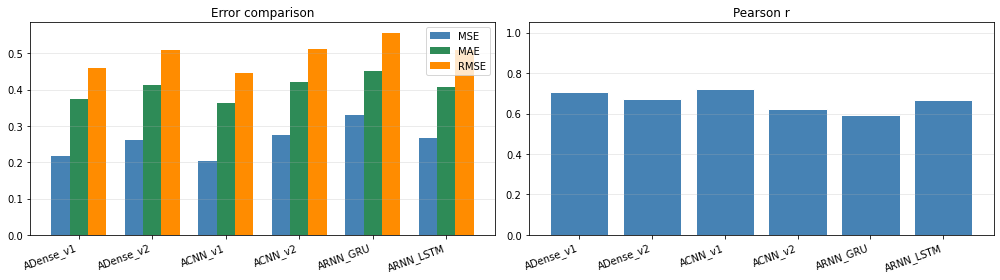

In [14]:
summary=pd.DataFrame(all_variant_results)[['note','model_type','n_params','MSE','MAE','RMSE','r']]
summary=summary.sort_values('MSE').reset_index(drop=True)
print(summary.to_string(index=False,float_format='{:.4f}'.format))
summary.to_csv(os.path.join(PLOTS_DIR,'summary.csv'),index=False)

fig,axes=plt.subplots(1,2,figsize=(14,4))
notes=[r['note'] for r in all_variant_results]
x=np.arange(len(notes)); w=0.25
axes[0].bar(x-w,[r['MSE'] for r in all_variant_results],w,label='MSE',color='steelblue')
axes[0].bar(x,  [r['MAE'] for r in all_variant_results],w,label='MAE',color='seagreen')
axes[0].bar(x+w,[r['RMSE'] for r in all_variant_results],w,label='RMSE',color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels(notes,rotation=20,ha='right')
axes[0].set_title('Error comparison'); axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)

axes[1].bar(x,[r['r'] for r in all_variant_results],color='steelblue',edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(notes,rotation=20,ha='right')
axes[1].set_ylim(0,1.05); axes[1].set_title('Pearson r'); axes[1].grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,'comparison.png'),dpi=120); plt.show()


## Inference

In [15]:
def load_prod(project, device):
    client  = mlflow.MlflowClient()
    version = client.get_model_version_by_alias(project,'prod')
    run     = client.get_run(version.run_id)
    model   = mlflow.pytorch.load_model(f'models:/{project}@prod',map_location=device).to(device)
    model.eval()
    scaler=None
    try:
        arts=[a.path for a in client.list_artifacts(version.run_id) if a.path.startswith('scaler_')]
        if arts:
            scaler=joblib.load(client.download_artifacts(version.run_id,arts[0]))
    except: pass
    mt=run.data.params.get('model_type','dense')
    print(f'Loaded @prod: {run.data.params.get("note")}  type={mt}')
    return model,scaler,mt


def predict_score(filepath, model, scaler, model_type, device,
                   feat_cols=FEAT_COLS):
    df     = pd.read_csv(filepath)
    cut_df = cut_with_model(df, ss_model, SS_CONFIG, device)
    if cut_df is None:
        return None
    arr      = cut_df[feat_cols].values.astype('float32')
    enriched = add_features(arr, feat_cols)
    fixed    = to_fixed_length(enriched, C)
    X = fixed.flatten()[None,:] if model_type=='dense' else fixed[None,:,:]
    if scaler is not None:
        X=scaler.transform(X.reshape(1,-1)).reshape(X.shape)
    model.eval()
    with torch.no_grad():
        score=model(torch.tensor(X,dtype=torch.float32,device=device)).item()
    return float(np.clip(score,0,SCORE_MAX))


reg_model, reg_scaler, reg_type = load_prod(PROJECT, device)

TEST_FILE = all_csv[0]
key       = os.path.splitext(os.path.basename(TEST_FILE))[0].replace('_kinect','')
pred      = predict_score(TEST_FILE, reg_model, reg_scaler, reg_type, device)
gt        = scores_map.get(key,'N/A')

print(f'File      : {os.path.basename(TEST_FILE)}')
print(f'Predicted : {pred:.4f}')
print(f'GT score  : {gt}')


Loaded @prod: ACNN_v1  type=cnn
File      : A100_kinect.csv
Predicted : 2.7023
GT score  : 3.2489820028351226
